In [1]:
'''
Notebook for developing one-to-one sensitivity analysis figure
'''

__author__ =  'Christian Dewey'
__date__   =  '29 December 2025'
__version__ = '0.1.0'

import os
import sys
from pathlib import Path

from h5py import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pflotranutils.h5_output.calc.cross_section import CrossSection 

# Add shared module to path
sys.path.insert(0, str(Path.cwd().parent))
#sys.path.insert(0, str(Path(__file__).parent / 'shared'))
from processing.pflotran import PflotranProcessor, Region

# Add results directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'results'))

# Add model-output directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'model-output'))

# Add observation data directory to path
OBS_PATH = str(Path.cwd().parent.parent / 'data/observational')


#### Initialize PFLOTRAN results processor

In [8]:
chem_obs_mzt19 = pd.read_csv(OBS_PATH + "/porewater/mz_2019_porewater.csv", parse_dates=['Date'])
chem_obs_mzt18 = pd.read_csv(OBS_PATH + "/porewater/mz_2018_porewater.csv", parse_dates=['Date'])
chem_obs_mcp19 = pd.read_csv(OBS_PATH + "/porewater/mc_2019_porewater.csv", parse_dates=['Date'])

water_obs_mzt18 = pd.read_csv(OBS_PATH + "/gw-elevs-z/groundwater_elevs_ALL.csv", parse_dates=['Date and time'])

In [3]:
spin_outputs = [
    "mcp19/2026-02-02/2026-02-02_20-54-36/pflotran-mcp19_2026-02-02_20-54-36_spin.h5"
]
simulation_outputs = [
    "mcp19/2026-02-02/2026-02-02_20-54-36/pflotran-mcp19_2026-02-02_20-54-36.h5"
]

components = [
    'Total_HCO3- [M]',
    'Total_SO4-- [M]',
    'Total_Ca++ [M]',
    'Total_Fe++ [M]',
    'pH'
]

In [6]:
'''processor_mzt18_spin_2 = PflotranProcessor(h5_path=spin_outputs[0], 
                         meander='MZ',
                         perpendicular_axis='x')'''

processor_mzt18 = PflotranProcessor(h5_path=simulation_outputs[0], 
                         meander='MZ',
                         perpendicular_axis='x')

In [20]:
print(chem_obs_mcp19.columns)

Index(['Well', 'Date', 'Time', 'pH', 'Cond', 'ORP', 'Temp', 'DO', 'TC', 'NPOC',
       'TIC', 'NH4', 'Cl', 'NO2', 'SO4', 'NO3', 'Li', 'sd', 'Be', 'sd.1', 'B',
       'sd.2', 'Na', 'sd.3', 'Mg', 'sd.4', 'Al', 'sd.5', 'Si', 'sd.6', 'Si-1',
       'sd.7', 'K', 'sd.8', 'V', 'sd.9', 'Cr', 'sd.10', 'Mn', 'sd.11', 'Ca',
       'sd.12', 'Fe', 'sd.13', 'Se', 'sd.14', 'SeO', 'sd.15', 'Ti', 'sd.16',
       'Ni', 'sd.17', 'Co', 'sd.18', 'Cu', 'sd.19', 'Zn', 'sd.20', 'Ge',
       'sd.21', 'As', 'sd.22', 'Rb', 'sd.23', 'Sr', 'sd.24', 'Zr', 'sd.25',
       'Mo', 'sd.26', 'Ag', 'sd.27', 'Cd', 'sd.28', 'Sn', 'sd.29', 'Sb',
       'sd.30', 'Cs', 'sd.31', 'Ba', 'sd.32', 'Eu', 'sd.33', 'Pb', 'sd.34',
       'Th', 'sd.35', 'U', 'sd.36', 'PO', 'sd.37', 'AsO', 'sd.38'],
      dtype='str')


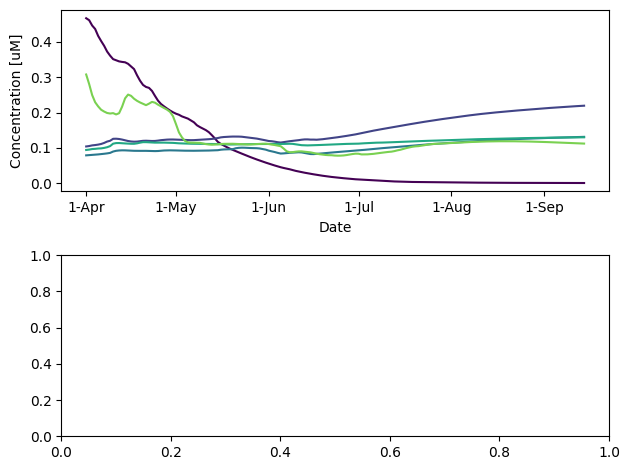

In [27]:
fig, axs = plt.subplots(2,1)
startdate = np.datetime64('2019-04-01')
processor_mzt18.plot_component_histories(component_name='Total_Fe++ [M]', startdate=startdate, ax=axs[0], unit='uM', chem_obs=chem_obs_mcp19)
#processor_mzt18_spin_2.plot_component_histories(component_name='Total_SO4-- [M]', startdate=None, ax=axs[1], unit='mM', chem_obs=chem_obs_mzt18)
fig.tight_layout()

In [22]:
pp = processor_mzt18
startdate = np.datetime64('2019-05-01')
chem_obs = chem_obs_mcp19
water_obs = water_obs_mzt18 

In [23]:
stats = pp.calculate_kge(                                                                                    
    startdate=startdate,                                                                          
    chem_obs=chem_obs                                                                                       
) 

df = stats['summary']

ValueError: No components with matching observation data found

In [24]:
def get_component_sub_list(simple_components, component_list):

    component_sublist = []
    for full_component in component_list:
        for simple_component in simple_components:
            if simple_component in full_component:
                component_sublist.append(full_component)

    return component_sublist

component_sub = get_component_sub_list(['Fe',
                                        'HCO3',
                                        'SO4',
                                        'Ca++'], 
                                        df['Component'])

sub_df = df[df['Component'].isin(component_sub)]

print(sub_df)

          Component  Obs       KGE        NSE          RMSE         r  \
0    Total_Fe++ [M]   Fe -0.845226  -0.722089  8.312377e-07 -0.363144   
1     Free_Fe++ [M]   Fe -0.846987  -0.884631  8.695821e-07 -0.244089   
2   Total_SO4-- [M]  SO4 -0.256147  -1.093977  2.816708e-04  0.106444   
3    Free_SO4-- [M]  SO4 -0.341745  -1.665154  3.177730e-04  0.062625   
4    Total_Ca++ [M]   Ca -0.990558 -40.657927  2.536959e-03  0.390894   
5     Free_Ca++ [M]   Ca -0.778004 -32.746993  2.283401e-03  0.392529   
14  Total_HCO3- [M]  TIC -2.255709 -78.563917  7.059762e-03  0.441874   
15   Free_HCO3- [M]  TIC -0.294380 -16.164618  3.279058e-03  0.491664   

           α         β    n  
0   0.073014  0.170907   85  
1   0.020975  0.048625   85  
2   0.237059  0.555722  117  
3   0.210787  0.453420  117  
4   2.208349  2.459865  116  
5   2.037586  2.309844  116  
14  3.742270  2.663759  115  
15  1.911051  1.766158  115  


Kling-Gupta for Total_HCO3- [M]


ValueError: No components with matching observation data found

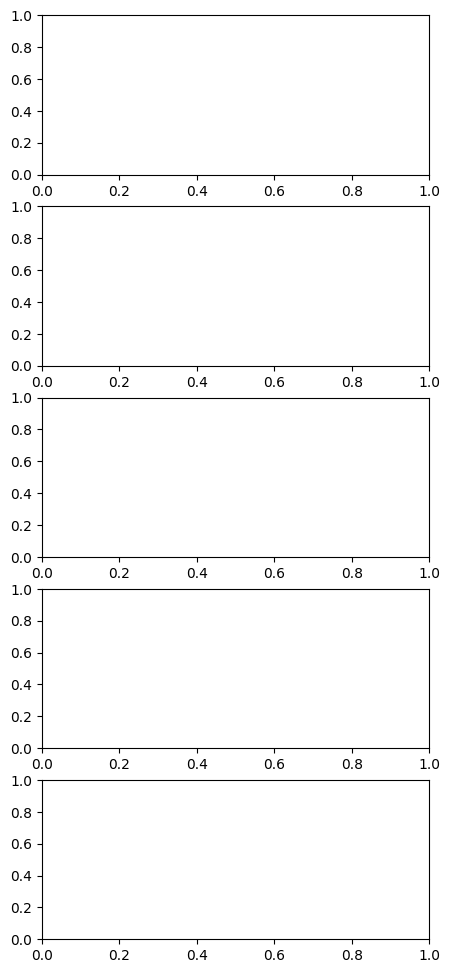

In [25]:
fig, axs = plt.subplots(len(components),1, figsize = (5,12))

for i in range(len(components)):
    print(f'Kling-Gupta for {components[i]}')
    stats = pp.calculate_kge(                                                                   
        component_name=components[i],                                                                              
        startdate=startdate,                                                         
        chem_obs=chem_obs                                                                               
    )                                                                                                  
    print(f"KGE: {stats['kge']:.3f}")                                                                                   
    print(f"  r (correlation): {stats['kge_components']['r']:.3f}")                                                     
    print(f"  a (variability): {stats['kge_components']['alpha']:.3f}")                                                 
    print(f"  β (bias ratio):  {stats['kge_components']['beta']:.3f}\n")   

    axs[i] = pp.plot_component_histories(component_name=components[i], startdate=startdate, ax=axs[i], unit='mM', chem_obs=chem_obs)

    axs[i].set_title(f'{components[i]}')

fig.tight_layout()


--- Validation Stats: Free_HCO3- [M] ---
  R²    = 0.703
  NSE   = 0.086
  KGE   = 0.777
  RMSE  = 7.45e-01
  Bias  = -6.00e-01
  Slope = 0.828
  n     = 120

--- Validation Stats: Total_HCO3- [M] ---
  R²    = 0.735
  NSE   = 0.549
  KGE   = 0.689
  RMSE  = 5.23e-01
  Bias  = -8.17e-02
  Slope = 1.093
  n     = 120

--- Validation Stats: pH ---
  R²    = 0.336
  NSE   = 0.187
  KGE   = 0.573
  RMSE  = 1.88e-01
  Bias  = -3.75e-02
  Slope = 0.535
  n     = 80

--- Validation Stats: Total_Ca++ [M] ---
  R²    = 0.485
  NSE   = -0.651
  KGE   = 0.563
  RMSE  = 5.05e-01
  Bias  = 3.64e-01
  Slope = 0.852
  n     = 116


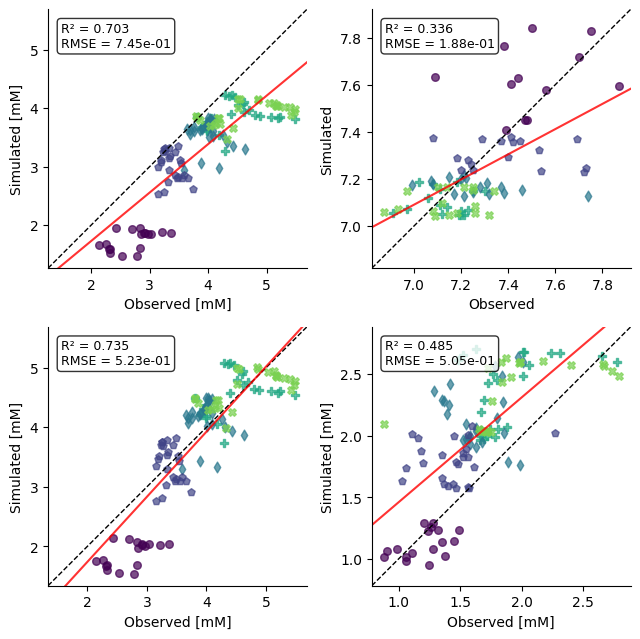

In [48]:
fig, axs = plt.subplots(2,2,figsize=(6.5, 6.5))

ax = axs[0,0]
ax = pp.plot_validation(
    'Free_HCO3- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax, 
    show_legend=False
)
ax.set_title('')

ax = axs[1,0]
ax = pp.plot_validation(
    'Total_HCO3- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[0,1]
ax = pp.plot_validation(
    'pH',
    startdate=startdate,
    chem_obs=chem_obs,
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[1,1]
ax = pp.plot_validation(
    'Total_Ca++ [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

sns.despine()

fig.tight_layout()